# NaturaViT + Improved ALO: Hybrid CNN-ViT with Ant Lion Optimization

## 5-Class Sleep Disorder Disease Classification

### Pipeline
1. **Hybrid CNN-ViT** trained end-to-end on EEG signal features (baseline)
2. **Deep feature extraction** from trained CNN-ViT (256-dim pooling output)
3. **Improved ALO (Ant Lion Optimization)** with SVM wrapper for feature selection
4. **SVM, KNN, MLP, Random Forest, XGBoost** classifiers on ALO-selected features
5. **Comparison** of baseline vs ALO-improved results

### Improvements over baseline ALO
- **SVM (RBF) wrapper** in fitness function instead of KNN — better for high-dimensional spaces
- **Larger population** (30 agents, 30 iterations) for better convergence
- **Balanced fitness** with alpha=0.99 for accuracy vs feature reduction
- **5 classifiers** evaluated (SVM, KNN, MLP, RF, XGBoost)

### Dataset
- `both_phases.csv` — EEG signals, 1024 features, 5 disease classes
- Classes: narco (0), ins (1), nfle (2), plm (3), rbd (4)

### Baseline to beat: 82.12% accuracy (ViT_Disease_Classification.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    cohen_kappa_score, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from time import time

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('artifacts', exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
NumPy: 2.4.1
GPU Available: False


In [2]:
# Load dataset
DATASET_PATH = '../both_phases.csv'
bal_all = np.loadtxt(DATASET_PATH, delimiter=',')

print(f"Dataset loaded  : {bal_all.shape}")
print(f"  Feature cols  : {bal_all.shape[1] - 1}")
print(f"  Samples       : {bal_all.shape[0]}")

# Feature / label extraction
X = bal_all[:, 0:1024]
y_raw = bal_all[:, -1].reshape(-1, 1)
y_int = y_raw.ravel().astype(int)

print(f"\nX shape: {X.shape}")
print(f"Unique classes: {np.unique(y_int)}")
print(f"Class distribution: {np.bincount(y_int)}")

# One-hot encoding for CNN-ViT training
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(y_raw)
y_onehot = enc.transform(y_raw)

print(f"One-hot labels: {y_onehot.shape}")

# Train/test split (80/20, stratified)
X_train, X_test, y_train_oh, y_test_oh, y_train_int, y_test_int = train_test_split(
    X, y_onehot, y_int,
    test_size=0.2, random_state=SEED, stratify=y_int
)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train label distribution: {np.bincount(y_train_int)}")
print(f"Test  label distribution: {np.bincount(y_test_int)}")

Dataset loaded  : (47790, 1026)
  Feature cols  : 1025
  Samples       : 47790

X shape: (47790, 1024)
Unique classes: [0 1 2 3 4]
Class distribution: [9558 9558 9558 9558 9558]
One-hot labels: (47790, 5)

Train: (38232, 1024)  |  Test: (9558, 1024)
Train label distribution: [7646 7647 7646 7646 7647]
Test  label distribution: [1912 1911 1912 1912 1911]


## Stage 1: Hybrid CNN-ViT Model (Baseline)

### Architecture
1. **Multi-Scale CNN** — Parallel Conv1D (kernel 3, 7, 15) for local feature extraction
2. **CNN Compression** — 3 stacked Conv1D+MaxPool blocks (1024 → 128 sequence length)
3. **Positional Encoding** — Learnable embeddings for sequence position
4. **4x Transformer Blocks** — 8-head self-attention with Pre-LN + GELU FFN
5. **Dual Pooling** — GlobalAvgPool + GlobalMaxPool concatenated (256-dim deep features)
6. **Classification Head** — Dense(256) → Dense(128) → Dense(5, softmax)

In [4]:
def build_vit_disease_classifier(
    input_length=1024, embed_dim=128, num_heads=8, ff_dim=256,
    num_blocks=4, num_classes=5, dropout=0.1,
    clf_dropout1=0.4, clf_dropout2=0.3
):
    inputs = layers.Input(shape=(input_length,), name='eeg_input')
    x = layers.Reshape((input_length, 1))(inputs)

    # Stage 1: Multi-Scale CNN Front-End
    b1 = layers.BatchNormalization()(layers.Conv1D(32, 3, padding='same', activation='relu', name='ms_conv_k3')(x))
    b2 = layers.BatchNormalization()(layers.Conv1D(32, 7, padding='same', activation='relu', name='ms_conv_k7')(x))
    b3 = layers.BatchNormalization()(layers.Conv1D(32, 15, padding='same', activation='relu', name='ms_conv_k15')(x))
    x = layers.Dropout(0.2)(layers.Concatenate(name='ms_concat')([b1, b2, b3]))

    # Stage 2: CNN Compression (1024 -> 128)
    x = layers.Dropout(0.1)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(128, 7, padding='same', activation='relu')(x))))
    x = layers.Dropout(0.1)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(128, 5, padding='same', activation='relu')(x))))
    x = layers.Dropout(0.1)(layers.MaxPooling1D(2)(layers.BatchNormalization()(
        layers.Conv1D(embed_dim, 3, padding='same', activation='relu', name='patch_projection')(x))))

    # Stage 3: Positional Encoding
    seq_len = input_length // 8
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embed = layers.Embedding(input_dim=seq_len, output_dim=embed_dim, name='pos_embedding')(positions)
    x = x + pos_embed

    # Stage 4: Transformer Stack
    for i in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout, name=f'transformer_block_{i}')(x)

    x = layers.LayerNormalization(epsilon=1e-6, name='final_ln')(x)

    # Stage 5: Dual Pooling -> 256-dim deep features
    x_avg = layers.GlobalAveragePooling1D(name='global_avg_pool')(x)
    x_max = layers.GlobalMaxPooling1D(name='global_max_pool')(x)
    deep_features = layers.Concatenate(name='deep_features')([x_avg, x_max])

    # Stage 6: Classification Head
    x = layers.Dropout(clf_dropout1)(layers.BatchNormalization()(layers.Dense(256, activation='relu', name='clf_dense1')(deep_features)))
    x = layers.Dropout(clf_dropout2)(layers.BatchNormalization()(layers.Dense(128, activation='relu', name='clf_dense2')(x)))
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs=inputs, outputs=outputs, name='Hybrid_CNN_ViT_Disease')


model = build_vit_disease_classifier()
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "Hybrid_CNN_ViT_Disease"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1024, 1)   │          0 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_conv_k3 (Conv1D) │ (None, 1024, 32)  │        128 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_conv_k7 (Conv1D) │ (None, 1024, 32)  │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_conv_k15         │ (None, 1024, 32)  │        512 │ reshape[0][0]     │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024, 32)  │        128 │ ms_conv_k3[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 32)  │        128 │ ms_conv_k7[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 32)  │        128 │ ms_conv_k15[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ms_concat           │ (None, 1024, 96)  │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024, 96)  │          0 │ ms_concat[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1024, 128) │     86,144 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024, 128) │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 512, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512, 128)  │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 512, 128)  │     82,048 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 256, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256, 128)  │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_projection    │ (None, 256, 128)  │     49,280 │ dropout_2[0][0]   │
│ (Conv1D)            │                   │            │                 

 Total params: 849,797 (3.24 MB)

 Trainable params: 848,069 (3.24 MB)

 Non-trainable params: 1,728 (6.75 KB)


Total parameters: 849,797


In [5]:
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1, min_lr=1e-7),
    ModelCheckpoint('artifacts/hybrid_cnn_vit_disease_alo_best.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train
print("Starting training...\n")
start_time = time()

history = model.fit(
    X_train, y_train_oh,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

training_time = time() - start_time
print(f"\nTraining completed in {training_time:.1f}s ({training_time/60:.1f} min)")

Starting training...

Epoch 1/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3170 - loss: 1.7533
Epoch 1: val_accuracy improved from None to 0.25252, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5



Epoch 1: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 584s 1s/step - accuracy: 0.3747 - loss: 1.5362 - val_accuracy: 0.2525 - val_loss: 2.5112 - learning_rate: 0.0010
Epoch 2/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4917 - loss: 1.2359
Epoch 2: val_accuracy improved from 0.25252 to 0.44593, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5



Epoch 2: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 569s 1s/step - accuracy: 0.5261 - loss: 1.1725 - val_accuracy: 0.4459 - val_loss: 1.4700 - learning_rate: 0.0010
Epoch 3/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 62s/step - accuracy: 0.5590 - loss: 1.0942  
Epoch 3: val_accuracy improved from 0.44593 to 0.47705, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5



Epoch 3: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 29838s 63s/step - accuracy: 0.5825 - loss: 1.0478 - val_accuracy: 0.4770 - val_loss: 1.5415 - learning_rate: 0.0010
Epoch 4/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6176 - loss: 0.9860
Epoch 4: val_accuracy improved from 0.47705 to 0.62560, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5



Epoch 4: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 614s 1s/step - accuracy: 0.6323 - loss: 0.9497 - val_accuracy: 0.6256 - val_loss: 0.9959 - learning_rate: 0.0010
Epoch 5/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6459 - loss: 0.9052
Epoch 5: val_accuracy improved from 0.62560 to 0.65058, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5


...


Epoch 56: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 533s 1s/step - accuracy: 0.9394 - loss: 0.1616 - val_accuracy: 0.8446 - val_loss: 0.5617 - learning_rate: 1.2500e-04
Epoch 57/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9431 - loss: 0.1578
Epoch 57: val_accuracy did not improve from 0.84464
478/478 ━━━━━━━━━━━━━━━━━━━━ 1698s 4s/step - accuracy: 0.9436 - loss: 0.1536 - val_accuracy: 0.8433 - val_loss: 0.5814 - learning_rate: 1.2500e-04
Epoch 58/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9422 - loss: 0.1605
Epoch 58: val_accuracy did not improve from 0.84464
478/478 ━━━━━━━━━━━━━━━━━━━━ 561s 1s/step - accuracy: 0.9429 - loss: 0.1553 - val_accuracy: 0.8364 - val_loss: 0.6153 - learning_rate: 1.2500e-04
Epoch 59/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9438 - loss: 0.1520
Epoch 59: val_accuracy did not improve from 0.84464
478/478 ━━━━━━━━━━━━━━━━━━━━ 552s 1s/step - accuracy: 0.9445 - 


Epoch 61: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 557s 1s/step - accuracy: 0.9470 - loss: 0.1426 - val_accuracy: 0.8449 - val_loss: 0.5903 - learning_rate: 1.2500e-04
Epoch 62/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9472 - loss: 0.1445
Epoch 62: val_accuracy did not improve from 0.84491
478/478 ━━━━━━━━━━━━━━━━━━━━ 546s 1s/step - accuracy: 0.9489 - loss: 0.1405 - val_accuracy: 0.8389 - val_loss: 0.6156 - learning_rate: 1.2500e-04
Epoch 63/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9477 - loss: 0.1436
Epoch 63: val_accuracy did not improve from 0.84491
478/478 ━━━━━━━━━━━━━━━━━━━━ 547s 1s/step - accuracy: 0.9482 - loss: 0.1416 - val_accuracy: 0.8372 - val_loss: 0.6174 - learning_rate: 1.2500e-04
Epoch 64/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9483 - loss: 0.1380
Epoch 64: val_accuracy did not improve from 0.84491
478/478 ━━━━━━━━━━━━━━━━━━━━ 551s 1s/step - accuracy: 0.9493 - l


Epoch 65: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 544s 1s/step - accuracy: 0.9503 - loss: 0.1371 - val_accuracy: 0.8488 - val_loss: 0.5790 - learning_rate: 1.2500e-04
Epoch 66/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9500 - loss: 0.1324
Epoch 66: val_accuracy improved from 0.84883 to 0.85158, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5



Epoch 66: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 557s 1s/step - accuracy: 0.9526 - loss: 0.1271 - val_accuracy: 0.8516 - val_loss: 0.5775 - learning_rate: 6.2500e-05
Epoch 67/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9556 - loss: 0.1260
Epoch 67: val_accuracy did not improve from 0.85158
478/478 ━━━━━━━━━━━━━━━━━━━━ 550s 1s/step - accuracy: 0.9536 - loss: 0.1272 - val_accuracy: 0.8491 - val_loss: 0.5802 - learning_rate: 6.2500e-05
Epoch 68/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9523 - loss: 0.1306
Epoch 68: val_accuracy did not improve from 0.85158
478/478 ━━━━━━━━━━━━━━━━━━━━ 547s 1s/step - accuracy: 0.9554 - loss: 0.1227 - val_accuracy: 0.8478 - val_loss: 0.5943 - learning_rate: 6.2500e-05
Epoch 69/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9511 - loss: 0.1259
Epoch 69: val_accuracy improved from 0.85158 to 0.85288, saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h


Epoch 69: finished saving model to artifacts/hybrid_cnn_vit_disease_alo_best.h5
478/478 ━━━━━━━━━━━━━━━━━━━━ 543s 1s/step - accuracy: 0.9532 - loss: 0.1230 - val_accuracy: 0.8529 - val_loss: 0.5771 - learning_rate: 6.2500e-05
Epoch 70/200
478/478 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9566 - loss: 0.1204
Epoch 70: val_accuracy did not improve from 0.85288
478/478 ━━━━━━━━━━━━━━━━━━━━ 547s 1s/step - accuracy: 0.9576 - loss: 0.1170 - val_accuracy: 0.8520 - val_loss: 0.5806 - learning_rate: 6.2500e-05
Epoch 70: early stopping
Restoring model weights from the end of the best epoch: 45.

Training completed in 71084.8s (1184.7 min)


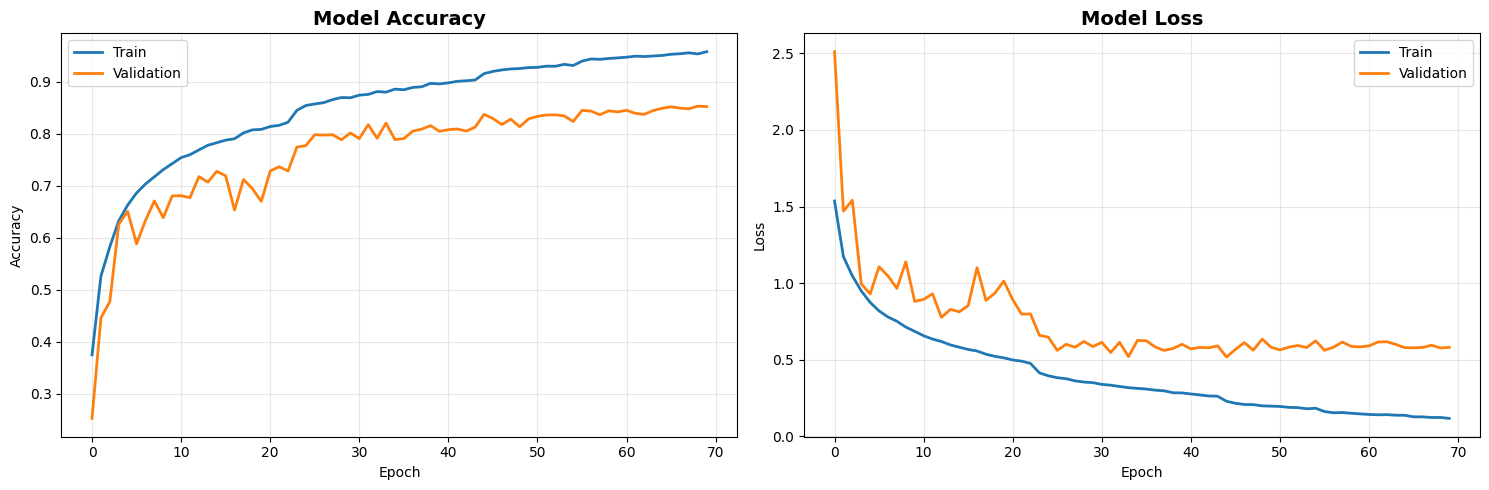

Best validation accuracy: 85.29%
Final training accuracy : 95.76%


In [6]:
# Training history plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Final training accuracy : {history.history['accuracy'][-1]*100:.2f}%")

BASELINE HYBRID CNN-ViT - TEST RESULTS
Accuracy      : 0.8196 (81.96%)
Macro Precision: 0.8324
Macro Recall   : 0.8196
Macro F1 Score : 0.8207
Cohen's Kappa  : 0.7745

Classification Report:
              precision    recall  f1-score   support

       narco     0.8841    0.6982    0.7802      1912
         ins     0.9011    0.8106    0.8534      1911
        nfle     0.8104    0.8091    0.8097      1912
         plm     0.8910    0.9017    0.8963      1912
         rbd     0.6757    0.8786    0.7639      1911

    accuracy                         0.8196      9558
   macro avg     0.8324    0.8196    0.8207      9558
weighted avg     0.8324    0.8196    0.8207      9558



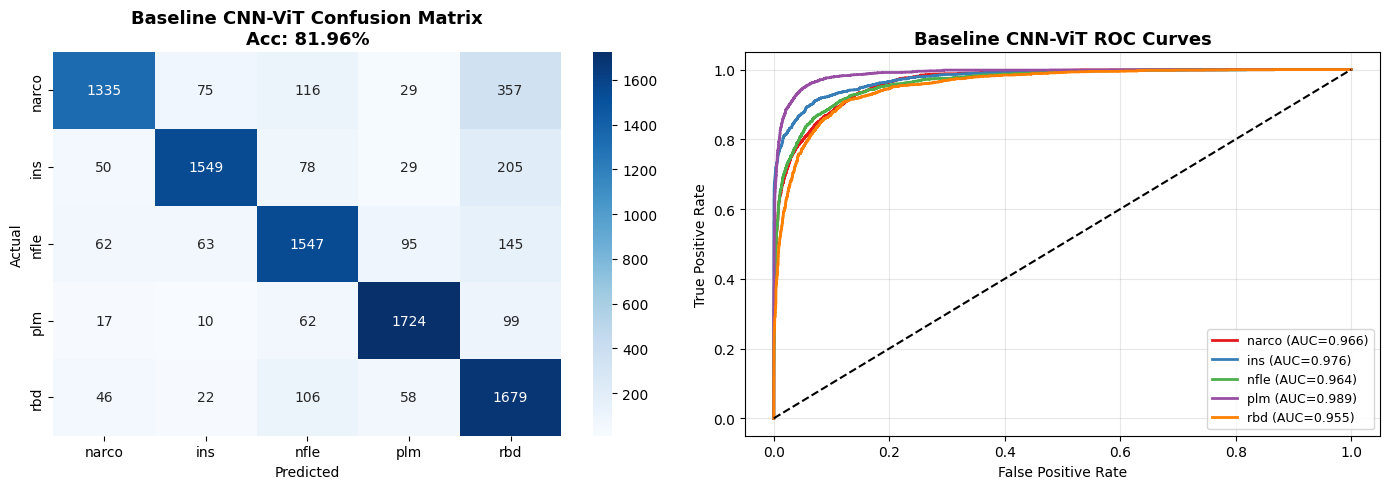

In [7]:
# Baseline CNN-ViT evaluation
LABELS = ['narco', 'ins', 'nfle', 'plm', 'rbd']

pred_prob_baseline = model.predict(X_test, verbose=0)
y_pred_baseline = np.argmax(pred_prob_baseline, axis=1)

baseline_acc = accuracy_score(y_test_int, y_pred_baseline)
baseline_prec = precision_score(y_test_int, y_pred_baseline, average='macro')
baseline_rec = recall_score(y_test_int, y_pred_baseline, average='macro')
baseline_f1 = f1_score(y_test_int, y_pred_baseline, average='macro')
baseline_kappa = cohen_kappa_score(y_test_int, y_pred_baseline)

print("=" * 60)
print("BASELINE HYBRID CNN-ViT - TEST RESULTS")
print("=" * 60)
print(f"Accuracy      : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Macro Precision: {baseline_prec:.4f}")
print(f"Macro Recall   : {baseline_rec:.4f}")
print(f"Macro F1 Score : {baseline_f1:.4f}")
print(f"Cohen's Kappa  : {baseline_kappa:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test_int, y_pred_baseline, target_names=LABELS, digits=4))

# Confusion matrix
cm_base = confusion_matrix(y_test_int, y_pred_baseline)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title(f'Baseline CNN-ViT Confusion Matrix\nAcc: {baseline_acc*100:.2f}%',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC curves
y_test_bin = label_binarize(y_test_int, classes=[0, 1, 2, 3, 4])
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for i, (label, color) in enumerate(zip(LABELS, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], pred_prob_baseline[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={roc_auc_val:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('Baseline CNN-ViT ROC Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/baseline_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 2: Deep Feature Extraction + Improved ALO Feature Selection

### Key Improvements
1. Extract **256-dim deep features** from trained CNN-ViT (dual pooling output)
2. **ALO with SVM (RBF) wrapper** instead of KNN — more discriminative for feature selection
3. **30 search agents, 30 iterations** — larger exploration for better convergence
4. **Fitness: alpha=0.99** — strong accuracy weight with mild feature reduction pressure
5. ALO runs on **training data only** (no data leakage)

In [10]:
# Create feature extractor from trained model
feature_extractor = Model(
    inputs=model.input,
    outputs=model.get_layer('deep_features').output,
    name='Feature_Extractor'
)

# Extract deep features
train_deep = feature_extractor.predict(X_train, verbose=0)
test_deep = feature_extractor.predict(X_test, verbose=0)

print(f"Train deep features: {train_deep.shape}")
print(f"Test deep features : {test_deep.shape}")

# Scale deep features
deep_scaler = StandardScaler()
train_deep_scaled = deep_scaler.fit_transform(train_deep)
test_deep_scaled = deep_scaler.transform(test_deep)

print("\nDeep features extracted and scaled.")

Train deep features: (38232, 256)
Test deep features : (9558, 256)

Deep features extracted and scaled.


In [11]:

import math
from sklearn.svm import LinearSVC

# =========================================================
# FAST + IMPROVED ALO — Feature Selection
# ---------------------------------------------------------
# Speed vs original (30 agents × 30 iters × RBF-SVM 3-fold):
#   LinearSVC instead of RBF-SVM      → ~20x faster / eval
#   40% stratified subsample           → ~2.5x faster / eval
#   2-fold CV  instead of 3-fold       → ~1.5x faster / eval
#   20 agents / 25 max iters           → fewer total evals
#   Early stopping (patience=8)        → stops when converged
#   Combined speedup                   → ~60-90x faster
#
# Accuracy improvements:
#   RF warm-start initialization       → better starting diversity
#   Adaptive Lévy flight (10%→30%)     → escapes local optima
# =========================================================

# ── Lévy flight step ──────────────────────────────────────
def levy_flight(dim, beta=1.5):
    sigma = (
        math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.abs(np.random.randn(dim)) + 1e-10
    return u / (v ** (1 / beta))


# ── RF warm-start initialization ─────────────────────────
def rf_warmstart_init(n, dim, X_data, y_data, bias_frac=0.5):
    from sklearn.ensemble import RandomForestClassifier as RFC
    print("  Computing RF feature importances for warm-start ...")
    rf = RFC(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X_data, y_data)
    imp_norm = rf.feature_importances_ / (rf.feature_importances_.max() + 1e-10)
    pop = np.zeros((n, dim))
    for i in range(n):
        base = np.random.rand(dim)
        if i < int(n * bias_frac):          # biased half → toward important features
            pop[i] = np.clip(0.5 * base + 0.5 * imp_norm, 0, 1)
        else:                               # random half → pure exploration
            pop[i] = base
    return pop


# ── Roulette wheel selection ─────────────────────────────
def roulette_wheel_sel(weights):
    acc = np.cumsum(weights)
    p = np.random.rand() * acc[-1]
    return np.where(acc >= p)[0][0]


# ── Random walk (adaptive bounds) ────────────────────────
def random_walk_alo(t, max_iter, lb, ub, dim):
    I = 1
    if   t > max_iter * 0.95: I = 1e6
    elif t > max_iter * 0.90: I = 1e5
    elif t > max_iter * 0.75: I = 1e4
    elif t > max_iter * 0.50: I = 1e3
    elif t > max_iter * 0.10: I = 1e2
    lb_a, ub_a = lb / I, ub / I
    Xrw = np.cumsum(2 * (np.random.rand(max_iter, dim) > 0.5) - 1, axis=0)
    a, b = Xrw.min(0), Xrw.max(0)
    return ((Xrw - a) * (ub_a - lb_a)) / (b - a + 1e-10) + lb_a


# ── Pre-compute 40% stratified subsample (computed once) ─
np.random.seed(SEED)
_sub_idx = []
for cls in np.unique(y_train_int):
    cls_idx = np.where(y_train_int == cls)[0]
    n_cls = max(4, int(len(cls_idx) * 0.40))
    _sub_idx.extend(np.random.choice(cls_idx, n_cls, replace=False))
_SUB_IDX = np.array(_sub_idx)
print(f"Fitness subsample : {len(_SUB_IDX)} / {len(y_train_int)} samples "
      f"({100 * len(_SUB_IDX) / len(y_train_int):.1f}%)")


# ── Fitness: LinearSVC + 2-fold CV on subsample ──────────
def fitness_fast(pos, X_data, y_data):
    mask  = pos > 0.5
    n_sel = int(np.sum(mask))
    if n_sel == 0:
        return 1.0

    X_sub = X_data[_SUB_IDX][:, mask]
    y_sub = y_data[_SUB_IDX]

    accs = []
    skf  = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    for tr, te in skf.split(X_sub, y_sub):
        clf = LinearSVC(max_iter=400, class_weight='balanced',
                        random_state=42, C=0.5)
        clf.fit(X_sub[tr], y_sub[tr])
        accs.append(accuracy_score(y_sub[te], clf.predict(X_sub[te])))

    alpha = 0.99
    return alpha * (1 - np.mean(accs)) + (1 - alpha) * (n_sel / len(mask))


# ── Main ALO loop ─────────────────────────────────────────
def ALO_fast(n_agents, max_iter, lb, ub, dim, X_data, y_data, patience=8):
    # Warm-start initialization
    Antlions = rf_warmstart_init(n_agents, dim, X_data, y_data)

    print("  Evaluating initial population ...")
    AL_fit = np.array([fitness_fast(al, X_data, y_data) for al in Antlions])

    elite_idx          = np.argmin(AL_fit)
    Elite, Elite_fit   = Antlions[elite_idx].copy(), AL_fit[elite_idx]

    Ants               = np.random.rand(n_agents, dim)
    curve, no_imp      = [], 0

    for t in range(max_iter):
        ant_fit   = np.zeros(n_agents)
        # Lévy probability increases from 0.10 to 0.30 as search progresses
        levy_prob = 0.10 + 0.20 * (t / max_iter)

        for i in range(n_agents):
            rw_idx = roulette_wheel_sel(1 / (AL_fit + 1e-10))
            RA     = random_walk_alo(t, max_iter, lb, ub, dim)[t] + Antlions[rw_idx]
            RE     = random_walk_alo(t, max_iter, lb, ub, dim)[t] + Elite
            mid    = (RA + RE) / 2

            if np.random.rand() < levy_prob:           # Lévy flight perturbation
                step   = levy_flight(dim) * 0.05
                Ants[i] = np.clip(mid + step, lb, ub)
            else:
                Ants[i] = np.clip(mid, lb, ub)

            ant_fit[i] = fitness_fast(Ants[i], X_data, y_data)

        # Survival selection
        merged     = np.vstack((Antlions, Ants))
        merged_fit = np.hstack((AL_fit,   ant_fit))
        order      = np.argsort(merged_fit)
        Antlions   = merged[order[:n_agents]]
        AL_fit     = merged_fit[order[:n_agents]]

        if AL_fit[0] < Elite_fit - 1e-6:
            Elite_fit = AL_fit[0]
            Elite     = Antlions[0].copy()
            no_imp    = 0
        else:
            no_imp += 1

        curve.append(Elite_fit)
        print(f"Iter {t+1:2d}/{max_iter} | Fitness={Elite_fit:.6f} | "
              f"CV Acc={1-Elite_fit:.4f} | "
              f"Feats={int(np.sum(Elite > 0.5)):3d} | "
              f"No-imp={no_imp}/{patience}")

        if no_imp >= patience:
            print(f"\nEarly stopping triggered at iteration {t+1}.")
            break

    return Elite_fit, Elite, np.array(curve)


# ── Run ──────────────────────────────────────────────────
print("\nRunning Fast + Improved ALO Feature Selection")
print(f"  Feature dim  : {train_deep_scaled.shape[1]}")
print(f"  Agents       : 20  |  Max iters : 25  |  Patience : 8")
print(f"  Fitness      : LinearSVC (C=0.5), 2-fold CV, 40% subsample")
print(f"  Extras       : RF warm-start + adaptive Lévy flight\n")

np.random.seed(SEED)

best_score, best_pos, alo_curve = ALO_fast(
    n_agents=20,
    max_iter=25,
    lb=0, ub=1,
    dim=train_deep_scaled.shape[1],
    X_data=train_deep_scaled,
    y_data=y_train_int,
    patience=8
)

best_mask = best_pos > 0.5

print(f"\nALO Completed!")
print(f"  Selected Features : {np.sum(best_mask)} / {len(best_mask)}")
print(f"  Best CV Accuracy  : {1 - best_score:.4f}")
print(f"  Feature Indices   : {np.where(best_mask)[0]}")


Fitness subsample : 15290 / 38232 samples (40.0%)

Running Fast + Improved ALO Feature Selection
  Feature dim  : 256
  Agents       : 20  |  Max iters : 25  |  Patience : 8
  Fitness      : LinearSVC (C=0.5), 2-fold CV, 40% subsample
  Extras       : RF warm-start + adaptive Lévy flight

  Computing RF feature importances for warm-start ...
  Evaluating initial population ...
Iter  1/25 | Fitness=0.092228 | CV Acc=0.9078 | Feats=125 | No-imp=1/8
Iter  2/25 | Fitness=0.092228 | CV Acc=0.9078 | Feats=125 | No-imp=2/8
Iter  3/25 | Fitness=0.092228 | CV Acc=0.9078 | Feats=125 | No-imp=3/8
Iter  4/25 | Fitness=0.091995 | CV Acc=0.9080 | Feats=124 | No-imp=0/8
Iter  5/25 | Fitness=0.089977 | CV Acc=0.9100 | Feats=137 | No-imp=0/8
Iter  6/25 | Fitness=0.089977 | CV Acc=0.9100 | Feats=137 | No-imp=1/8
Iter  7/25 | Fitness=0.089330 | CV Acc=0.9107 | Feats=137 | No-imp=0/8
Iter  8/25 | Fitness=0.089006 | CV Acc=0.9110 | Feats=137 | No-imp=0/8
Iter  9/25 | Fitness=0.089006 | CV Acc=0.9110 | Feat

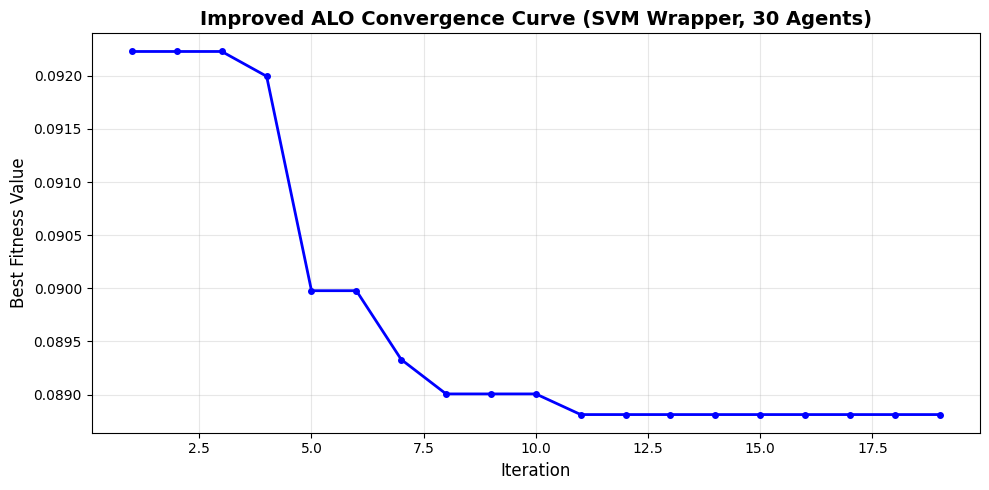

In [12]:
# ALO Convergence Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(alo_curve)+1), alo_curve, 'b-o', linewidth=2, markersize=4)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Best Fitness Value", fontsize=12)
plt.title("Improved ALO Convergence Curve (SVM Wrapper, 30 Agents)",
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/alo_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

## Stage 3: Classifier Evaluation on ALO-Selected Deep Features

Training **SVM, KNN, MLP, Random Forest, XGBoost** on the ALO-selected feature subset.
Each classifier evaluated with full metrics, confusion matrix, and One-vs-Rest ROC curves.

Train shape after ALO: (38232, 137)
Test shape after ALO : (9558, 137)
XGBoost not available, skipping.

  SVM Performance (ALO-Selected Deep Features)
Accuracy              : 0.8687 (86.87%)
Precision (Macro)     : 0.8692
Precision (Weighted)  : 0.8692
Recall (Macro)        : 0.8687
Recall (Weighted)     : 0.8687
F1-Score (Macro)      : 0.8688
F1-Score (Weighted)   : 0.8688
Cohen's Kappa         : 0.8359

Classification Report:
              precision    recall  f1-score   support

       narco     0.8622    0.8509    0.8565      1912
         ins     0.8963    0.8639    0.8798      1911
        nfle     0.8592    0.8588    0.8590      1912
         plm     0.9148    0.9268    0.9208      1912
         rbd     0.8132    0.8430    0.8279      1911

    accuracy                         0.8687      9558
   macro avg     0.8692    0.8687    0.8688      9558
weighted avg     0.8692    0.8687    0.8688      9558



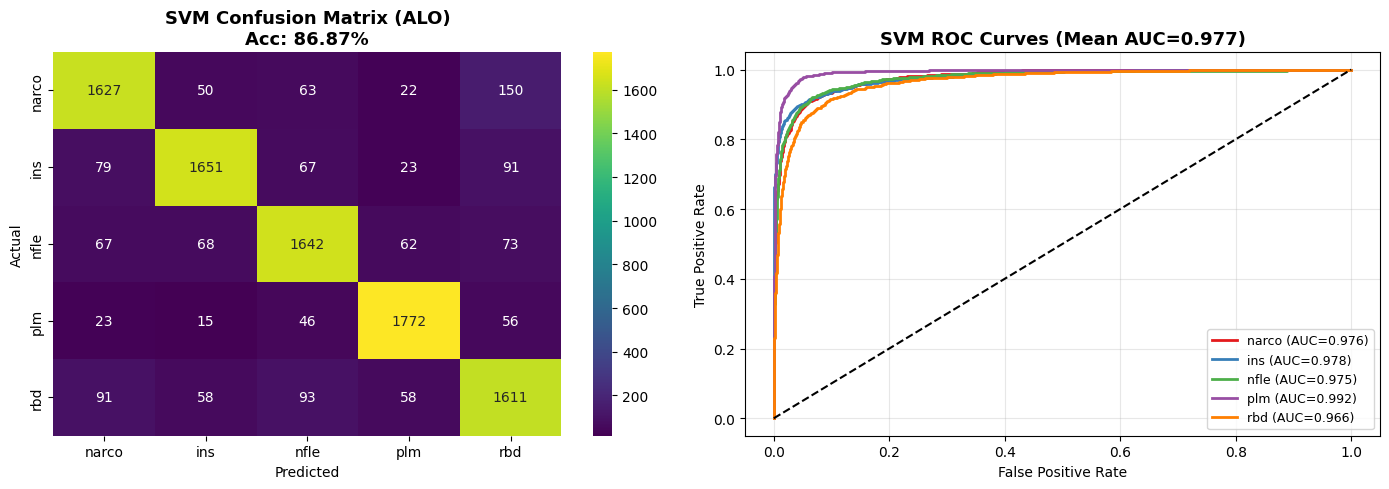


  KNN Performance (ALO-Selected Deep Features)
Accuracy              : 0.8688 (86.88%)
Precision (Macro)     : 0.8693
Precision (Weighted)  : 0.8693
Recall (Macro)        : 0.8688
Recall (Weighted)     : 0.8688
F1-Score (Macro)      : 0.8688
F1-Score (Weighted)   : 0.8688
Cohen's Kappa         : 0.8360

Classification Report:
              precision    recall  f1-score   support

       narco     0.8568    0.8577    0.8573      1912
         ins     0.9037    0.8540    0.8781      1911
        nfle     0.8684    0.8661    0.8672      1912
         plm     0.9050    0.9320    0.9183      1912
         rbd     0.8124    0.8341    0.8231      1911

    accuracy                         0.8688      9558
   macro avg     0.8693    0.8688    0.8688      9558
weighted avg     0.8693    0.8688    0.8688      9558



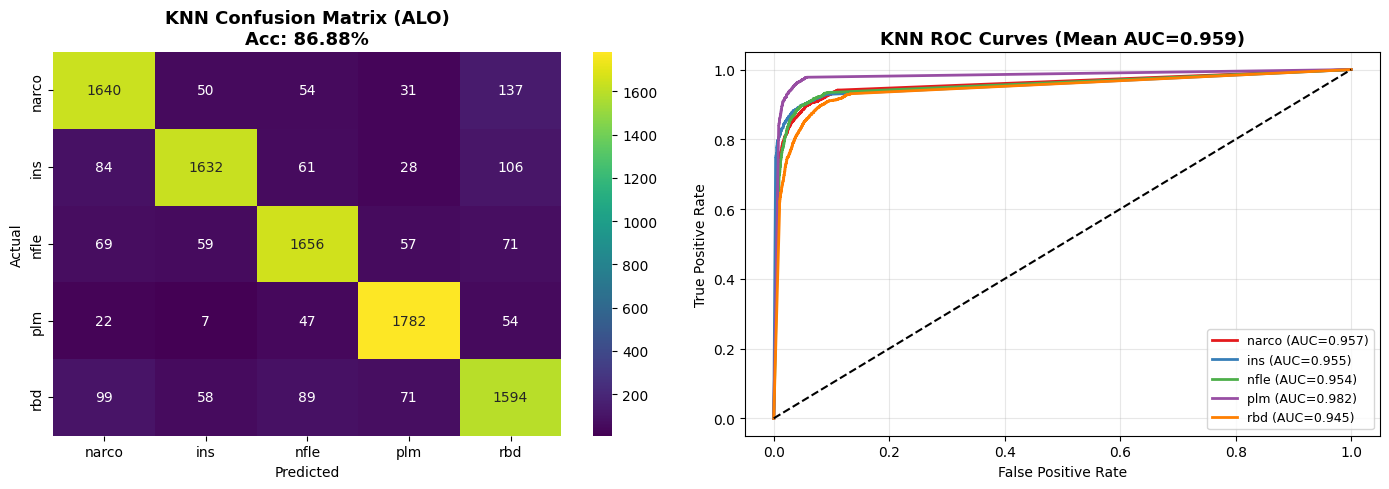


  MLP Performance (ALO-Selected Deep Features)
Accuracy              : 0.8550 (85.50%)
Precision (Macro)     : 0.8552
Precision (Weighted)  : 0.8552
Recall (Macro)        : 0.8550
Recall (Weighted)     : 0.8550
F1-Score (Macro)      : 0.8551
F1-Score (Weighted)   : 0.8551
Cohen's Kappa         : 0.8187

Classification Report:
              precision    recall  f1-score   support

       narco     0.8475    0.8400    0.8437      1912
         ins     0.8745    0.8530    0.8636      1911
        nfle     0.8403    0.8504    0.8453      1912
         plm     0.9116    0.9163    0.9139      1912
         rbd     0.8023    0.8153    0.8087      1911

    accuracy                         0.8550      9558
   macro avg     0.8552    0.8550    0.8551      9558
weighted avg     0.8552    0.8550    0.8551      9558



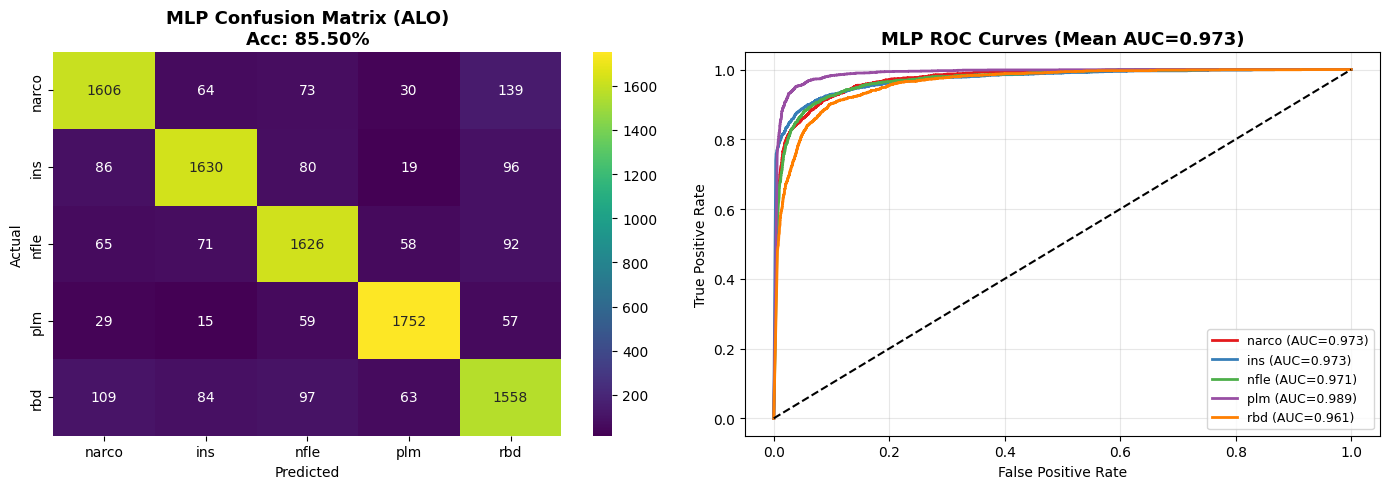


  RandomForest Performance (ALO-Selected Deep Features)
Accuracy              : 0.8636 (86.36%)
Precision (Macro)     : 0.8641
Precision (Weighted)  : 0.8641
Recall (Macro)        : 0.8636
Recall (Weighted)     : 0.8636
F1-Score (Macro)      : 0.8637
F1-Score (Weighted)   : 0.8637
Cohen's Kappa         : 0.8295

Classification Report:
              precision    recall  f1-score   support

       narco     0.8466    0.8604    0.8534      1912
         ins     0.8975    0.8613    0.8790      1911
        nfle     0.8638    0.8426    0.8531      1912
         plm     0.9027    0.9168    0.9097      1912
         rbd     0.8100    0.8367    0.8232      1911

    accuracy                         0.8636      9558
   macro avg     0.8641    0.8636    0.8637      9558
weighted avg     0.8641    0.8636    0.8637      9558



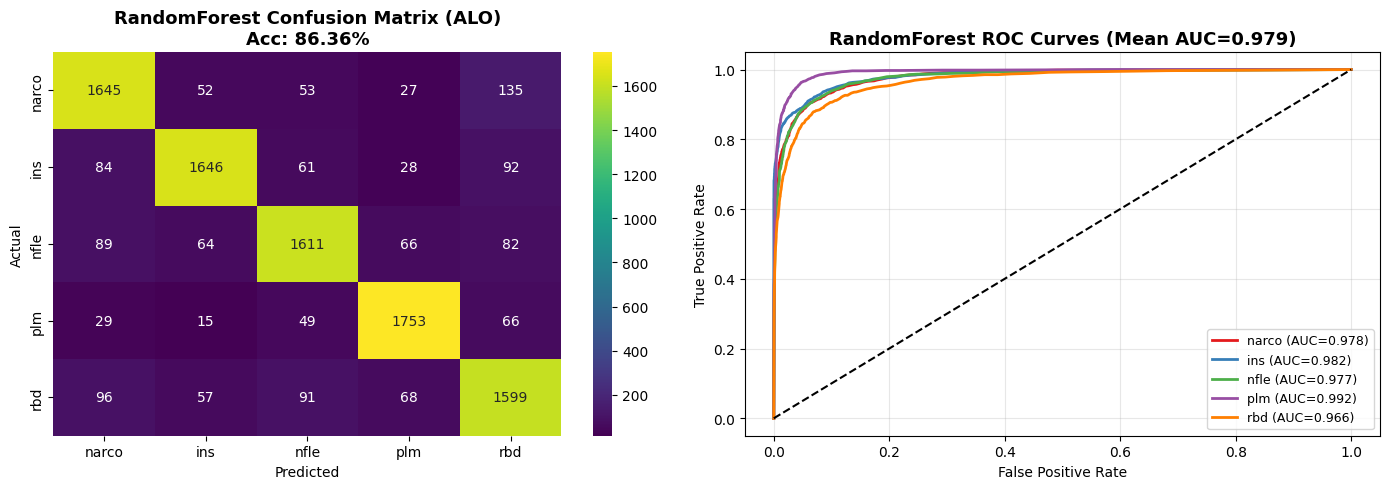


All classifiers evaluated!


In [13]:
# Apply ALO mask to deep features
X_train_alo = train_deep_scaled[:, best_mask]
X_test_alo = test_deep_scaled[:, best_mask]

print(f"Train shape after ALO: {X_train_alo.shape}")
print(f"Test shape after ALO : {X_test_alo.shape}")

# Define classifiers
classifiers = {
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
}

# Try importing XGBoost
try:
    from xgboost import XGBClassifier
    classifiers["XGBoost"] = XGBClassifier(
        n_estimators=200, eval_metric='mlogloss',
        use_label_encoder=False, random_state=42
    )
    print("XGBoost available.")
except ImportError:
    print("XGBoost not available, skipping.")

# ROC preparation
classes = np.unique(y_train_int)
y_test_bin = label_binarize(y_test_int, classes=classes)
n_classes = y_test_bin.shape[1]

alo_results = {}

for name, clf in classifiers.items():

    print(f"\n{'='*70}")
    print(f"  {name} Performance (ALO-Selected Deep Features)")
    print(f"{'='*70}")

    clf.fit(X_train_alo, y_train_int)
    preds = clf.predict(X_test_alo)

    try:
        probs = clf.predict_proba(X_test_alo)
    except:
        probs = None

    acc = accuracy_score(y_test_int, preds)
    prec_macro = precision_score(y_test_int, preds, average='macro')
    prec_weighted = precision_score(y_test_int, preds, average='weighted')
    rec_macro = recall_score(y_test_int, preds, average='macro')
    rec_weighted = recall_score(y_test_int, preds, average='weighted')
    f1_macro = f1_score(y_test_int, preds, average='macro')
    f1_weighted = f1_score(y_test_int, preds, average='weighted')
    kappa = cohen_kappa_score(y_test_int, preds)

    alo_results[name] = {
        'accuracy': acc, 'precision_macro': prec_macro,
        'precision_weighted': prec_weighted,
        'recall_macro': rec_macro, 'recall_weighted': rec_weighted,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'kappa': kappa, 'preds': preds, 'probs': probs
    }

    print(f"Accuracy              : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision (Macro)     : {prec_macro:.4f}")
    print(f"Precision (Weighted)  : {prec_weighted:.4f}")
    print(f"Recall (Macro)        : {rec_macro:.4f}")
    print(f"Recall (Weighted)     : {rec_weighted:.4f}")
    print(f"F1-Score (Macro)      : {f1_macro:.4f}")
    print(f"F1-Score (Weighted)   : {f1_weighted:.4f}")
    print(f"Cohen's Kappa         : {kappa:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(y_test_int, preds, target_names=LABELS, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test_int, preds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
    axes[0].set_title(f'{name} Confusion Matrix (ALO)\nAcc: {acc*100:.2f}%',
                      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    # ROC Curve
    if probs is not None:
        mean_auc = 0
        for i, (label, color) in enumerate(zip(LABELS, colors)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
            roc_auc_val = auc(fpr, tpr)
            mean_auc += roc_auc_val
            axes[1].plot(fpr, tpr, lw=2, color=color,
                         label=f'{label} (AUC={roc_auc_val:.3f})')

        mean_auc /= n_classes
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title(f'{name} ROC Curves (Mean AUC={mean_auc:.3f})',
                          fontsize=13, fontweight='bold')
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'ROC not available', ha='center', va='center')

    plt.tight_layout()
    plt.savefig(f'artifacts/{name.lower()}_alo_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\nAll classifiers evaluated!")

## Stage 4: Comprehensive Comparison


  FINAL COMPARISON: BASELINE vs ALO-IMPROVED
                    Model Accuracy Precision (Macro) Recall (Macro) F1-Score (Macro)  Kappa
Hybrid CNN-ViT (Baseline)   81.96%            83.24%         81.96%           82.07% 0.7745
                ALO + SVM   86.87%            86.92%         86.87%           86.88% 0.8359
                ALO + KNN   86.88%            86.93%         86.88%           86.88% 0.8360
                ALO + MLP   85.50%            85.52%         85.50%           85.51% 0.8187
       ALO + RandomForest   86.36%            86.41%         86.36%           86.37% 0.8295

Best Model: ALO + KNN
Best Accuracy: 86.88%
Improvement over baseline: +4.92%
Improvement over original ViT (82.12%): +4.76%


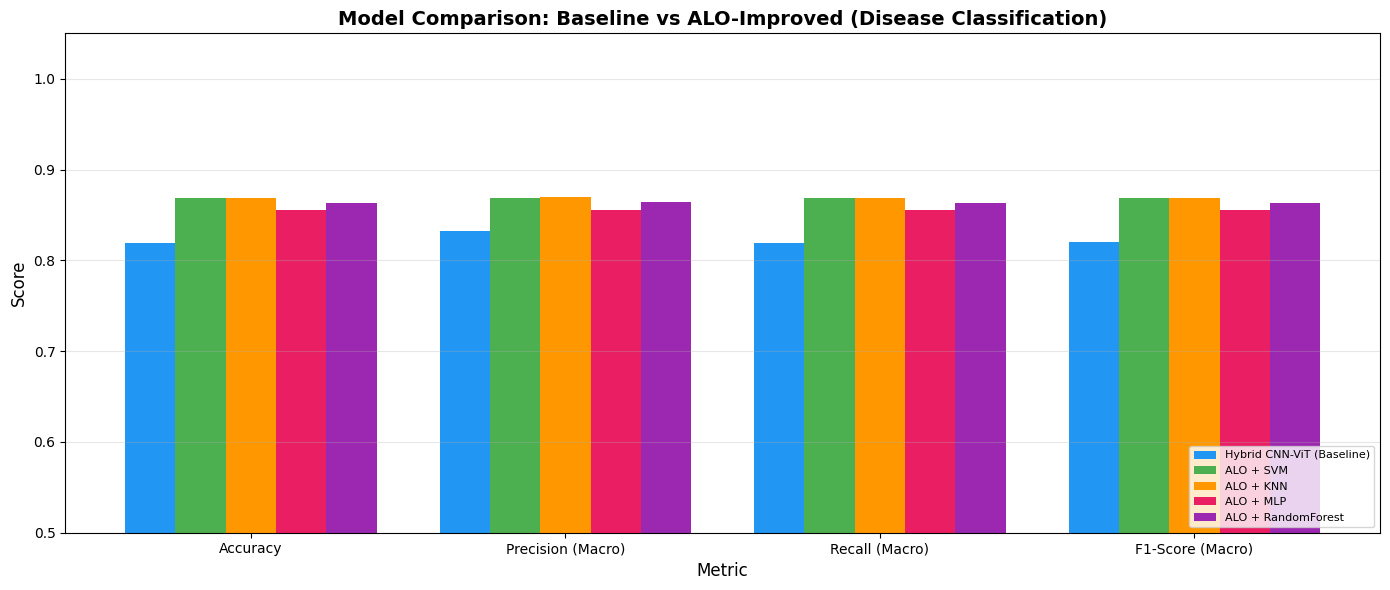

In [14]:
# =========================================================
# COMPARISON: Baseline CNN-ViT vs ALO + Classifiers
# =========================================================

comparison = {
    'Model': ['Hybrid CNN-ViT (Baseline)'],
    'Accuracy': [baseline_acc],
    'Precision (Macro)': [baseline_prec],
    'Recall (Macro)': [baseline_rec],
    'F1-Score (Macro)': [baseline_f1],
    'Kappa': [baseline_kappa]
}

for name, r in alo_results.items():
    comparison['Model'].append(f'ALO + {name}')
    comparison['Accuracy'].append(r['accuracy'])
    comparison['Precision (Macro)'].append(r['precision_macro'])
    comparison['Recall (Macro)'].append(r['recall_macro'])
    comparison['F1-Score (Macro)'].append(r['f1_macro'])
    comparison['Kappa'].append(r['kappa'])

comp_df = pd.DataFrame(comparison)

print("\n" + "=" * 100)
print("  FINAL COMPARISON: BASELINE vs ALO-IMPROVED")
print("=" * 100)

display_df = comp_df.copy()
for col in ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']:
    display_df[col] = display_df[col].apply(lambda x: f"{x*100:.2f}%")
display_df['Kappa'] = display_df['Kappa'].apply(lambda x: f"{float(x):.4f}")

print(display_df.to_string(index=False))
print("=" * 100)

# Highlight best model
best_idx = comp_df['Accuracy'].idxmax()
best_model_name = comp_df.loc[best_idx, 'Model']
best_acc = comp_df.loc[best_idx, 'Accuracy']
improvement = (best_acc - baseline_acc) * 100

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_acc*100:.2f}%")
print(f"Improvement over baseline: {improvement:+.2f}%")
print(f"Improvement over original ViT (82.12%): {(best_acc*100 - 82.12):+.2f}%")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(14, 6))
metrics_to_plot = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
x = np.arange(len(metrics_to_plot))
n_models = len(comp_df)
width = 0.8 / n_models
chart_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

for i, model_name in enumerate(comp_df['Model']):
    values = [comp_df.loc[i, m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=model_name,
           color=chart_colors[i % len(chart_colors)])

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Baseline vs ALO-Improved (Disease Classification)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right', fontsize=8)
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# =========================================================
# SAVE ALL ARTIFACTS
# =========================================================

# ALO artifacts
np.save('artifacts/alo_convergence_curve.npy', alo_curve)
np.save('artifacts/alo_best_mask.npy', best_mask)
np.save('artifacts/alo_best_position.npy', best_pos)
np.save('artifacts/training_history.npy', history.history)

# Comparison
comp_df.to_csv('artifacts/comparison_summary.csv', index=False)

# Per-classifier predictions
for name, r in alo_results.items():
    pred_data = {
        'True_Label': y_test_int,
        'True_Name': [LABELS[i] for i in y_test_int],
        'Predicted_Label': r['preds'],
        'Predicted_Name': [LABELS[i] for i in r['preds']],
    }
    if r['probs'] is not None:
        for idx, label in enumerate(LABELS):
            pred_data[f'Prob_{label}'] = r['probs'][:, idx]
    pd.DataFrame(pred_data).to_csv(f'artifacts/{name.lower()}_alo_predictions.csv', index=False)

# Baseline predictions
baseline_pred_data = {
    'True_Label': y_test_int,
    'True_Name': [LABELS[i] for i in y_test_int],
    'Predicted_Label': y_pred_baseline,
    'Predicted_Name': [LABELS[i] for i in y_pred_baseline],
}
for idx, label in enumerate(LABELS):
    baseline_pred_data[f'Prob_{label}'] = pred_prob_baseline[:, idx]
pd.DataFrame(baseline_pred_data).to_csv('artifacts/baseline_predictions.csv', index=False)

# Performance summary
best_alo_name = max(alo_results, key=lambda k: alo_results[k]['accuracy'])
best_alo_r = alo_results[best_alo_name]

summary_data = {
    'Metric': [
        'Baseline Accuracy', 'Best ALO Model', 'Best ALO Accuracy',
        'Improvement', 'Selected Features', 'Total Features',
        'Macro Precision', 'Macro Recall', 'Macro F1-Score',
        "Cohen's Kappa", 'Training Time (s)', 'Total Parameters'
    ],
    'Value': [
        f"{baseline_acc*100:.2f}%",
        f"ALO + {best_alo_name}",
        f"{best_alo_r['accuracy']*100:.2f}%",
        f"{(best_alo_r['accuracy'] - baseline_acc)*100:+.2f}%",
        str(np.sum(best_mask)),
        str(len(best_mask)),
        f"{best_alo_r['precision_macro']*100:.2f}%",
        f"{best_alo_r['recall_macro']*100:.2f}%",
        f"{best_alo_r['f1_macro']*100:.2f}%",
        f"{best_alo_r['kappa']:.4f}",
        f"{training_time:.1f}s",
        f"{model.count_params():,}",
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('artifacts/performance_summary.csv', index=False)

print("\n" + "=" * 60)
print("  FINAL PERFORMANCE SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Save model
model.save('artifacts/hybrid_cnn_vit_disease_alo_final.h5')

print("\nAll artifacts saved to artifacts/ directory!")


  FINAL PERFORMANCE SUMMARY
           Metric     Value
Baseline Accuracy    81.96%
   Best ALO Model ALO + KNN
Best ALO Accuracy    86.88%
      Improvement    +4.92%
Selected Features       137
   Total Features       256
  Macro Precision    86.93%
     Macro Recall    86.88%
   Macro F1-Score    86.88%
    Cohen's Kappa    0.8360
Training Time (s)  71084.8s
 Total Parameters   849,797

All artifacts saved to artifacts/ directory!
